# **Step 1: Data Loading and Initial Inspection**


In [4]:
# basic libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# load csv files (already in sample_data)
events = pd.read_csv("/content/cats_uk.csv")
ref = pd.read_csv("/content/cats_uk_reference 2.csv")

# quick checks
print("events shape:", events.shape)
print("ref shape:", ref.shape)

print("\nkey columns in events:", [c for c in ["tag_id","timestamp","location_lat","location_long","ground_speed","algorithm_marked_outlier"] if c in events.columns])
print("key columns in ref:", [c for c in ["tag_id","age_years","hrs_indoors","prey_p_month"] if c in ref.columns])

events.head()

events shape: (18215, 11)
ref shape: (101, 16)

key columns in events: ['tag_id', 'timestamp', 'location_lat', 'location_long', 'ground_speed', 'algorithm_marked_outlier']
key columns in ref: ['tag_id', 'age_years', 'hrs_indoors', 'prey_p_month']


,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,study_name
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,Pet Cats United Kingdom
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,Pet Cats United Kingdom
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,Pet Cats United Kingdom
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,Pet Cats United Kingdom
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,Pet Cats United Kingdom


In [5]:
# missingness check for key vars
print(events[["tag_id","timestamp","location_lat","location_long","ground_speed"]].isna().mean())
print(ref[["tag_id","age_years","hrs_indoors","prey_p_month"]].isna().mean())

tag_id           0.0
timestamp        0.0
location_lat     0.0
location_long    0.0
ground_speed     0.0
dtype: float64
tag_id          0.000000
age_years       0.009901
hrs_indoors     0.000000
prey_p_month    0.000000
dtype: float64


In this step, the two datasets were loaded and basic inspections were conducted, including checking data dimensions, key columns, and sample records. This helps ensure that the data structure is understood correctly before further processing and reduces the risk of errors in later stages.

# **Step 2: Background Attribute Exploration**

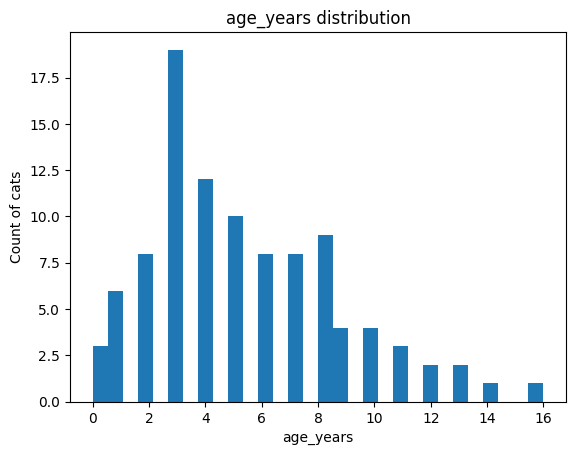

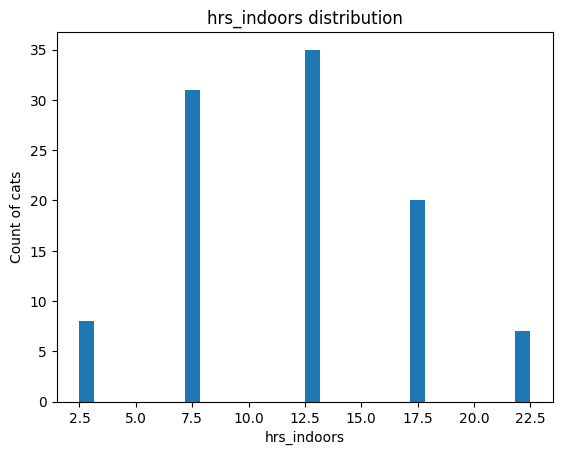

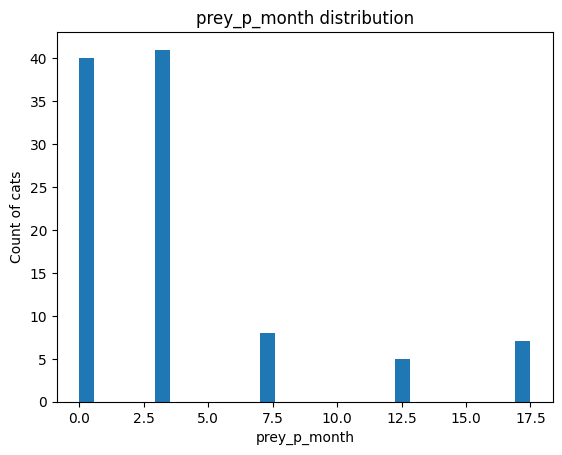

In [20]:
ref_cols = ["age_years", "hrs_indoors", "prey_p_month"]

for c in ref_cols:
    if c in ref.columns:
        plt.figure()
        plt.hist(ref[c].dropna(), bins=30)
        plt.xlabel(c)
        plt.ylabel("Count of cats")
        plt.title(f"{c} distribution")
        plt.show()

This figure summarizes the distributions of selected individual-level characteristics. The wide dispersion across variables such as age, indoor time, and hunting activity indicates strong heterogeneity among cats. These differences suggest that background characteristics may help contextualize observed movement patterns in later analysis.

# **Step 3: Movement Feature Aggregation at the Individual Level**

In [6]:
# aggregate movement features per cat
agg_df = events.groupby("tag_id").agg(
    mean_speed=("ground_speed", "mean"),
    p95_speed=("ground_speed", lambda x: np.percentile(x, 95)),
    outlier_rate=("algorithm_marked_outlier", "mean"),
    lat_std=("location_lat", "std"),
    lon_std=("location_long", "std"),
    event_count=("event_id", "count")
).reset_index()

agg_df.head()

,tag_id,mean_speed,p95_speed,outlier_rate,lat_std,lon_std,event_count
0,Abba-Tag,1603.951807,5763.6,0.012048,0.000407,0.001146,83
1,Alfie-Tag,1931.679144,5752.8,0.000000,0.000870,0.001753,187
2,Amber-Tag,1967.614679,6438.6,0.004587,0.002057,0.002686,218
3,Ares,2285.825243,7891.2,0.009709,0.000353,0.000569,103
4,Athena,2134.188679,5715.0,0.000000,0.000247,0.000416,106


Raw event-level movement data were aggregated at the individual cat level to generate summary behavioral features such as average speed and movement variability. This transformation reduces noise from individual observations and provides a more stable representation of each subject’s overall movement pattern.

# **Step 4: Feature Standardization and Attribute Integration**

**Step 4A: Normalize Movement Features**

In [7]:
# select movement feature columns
move_cols = ["mean_speed","p95_speed","outlier_rate","lat_std","lon_std","event_count"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
agg_df[move_cols] = scaler.fit_transform(agg_df[move_cols])

agg_df.head()

,tag_id,mean_speed,p95_speed,outlier_rate,lat_std,lon_std,event_count
0,Abba-Tag,-0.705667,-0.323168,-0.059882,-0.300471,-0.161639,-0.668797
1,Alfie-Tag,-0.169919,-0.327755,-0.947571,-0.178827,-0.033725,0.045711
2,Amber-Tag,-0.111174,-0.036477,-0.609597,0.132967,0.162716,0.258690
3,Ares,0.409017,0.580483,-0.232248,-0.314686,-0.283393,-0.531392
4,Athena,0.161131,-0.343810,-0.947571,-0.342490,-0.315494,-0.510781


Feature standardization was applied to movement-related variables to place them on a comparable scale. This step is important for clustering methods, as features with larger numeric ranges could otherwise dominate the distance calculations.

**Step 4B: Merge Individual Attributes**

In [8]:
# select individual attributes
attr_cols = ["tag_id","age_years","hrs_indoors","prey_p_month"]

merged_df = agg_df.merge(ref[attr_cols], on="tag_id", how="left")

merged_df.head()

,tag_id,mean_speed,p95_speed,outlier_rate,lat_std,lon_std,event_count,age_years,hrs_indoors,prey_p_month
0,Abba-Tag,-0.705667,-0.323168,-0.059882,-0.300471,-0.161639,-0.668797,3.0,7.5,3.0
1,Alfie-Tag,-0.169919,-0.327755,-0.947571,-0.178827,-0.033725,0.045711,3.0,7.5,3.0
2,Amber-Tag,-0.111174,-0.036477,-0.609597,0.132967,0.162716,0.258690,4.0,7.5,3.0
3,Ares,0.409017,0.580483,-0.232248,-0.314686,-0.283393,-0.531392,3.0,7.5,0.0
4,Athena,0.161131,-0.343810,-0.947571,-0.342490,-0.315494,-0.510781,3.0,7.5,3.0


After preparing movement features, individual-level attributes such as age and indoor hours were merged into the main dataset. This integration allows both behavioral and demographic factors to be considered simultaneously in the clustering process.

**Step 4C: Normalize Attributes**

In [9]:
attr_features = ["age_years","hrs_indoors","prey_p_month"]

merged_df[attr_features] = scaler.fit_transform(merged_df[attr_features])

merged_df.head()

,tag_id,mean_speed,p95_speed,outlier_rate,lat_std,lon_std,event_count,age_years,hrs_indoors,prey_p_month
0,Abba-Tag,-0.705667,-0.323168,-0.059882,-0.300471,-0.161639,-0.668797,-0.718522,-0.83745,-0.154462
1,Alfie-Tag,-0.169919,-0.327755,-0.947571,-0.178827,-0.033725,0.045711,-0.718522,-0.83745,-0.154462
2,Amber-Tag,-0.111174,-0.036477,-0.609597,0.132967,0.162716,0.258690,-0.421612,-0.83745,-0.154462
3,Ares,0.409017,0.580483,-0.232248,-0.314686,-0.283393,-0.531392,-0.718522,-0.83745,-0.778488
4,Athena,0.161131,-0.343810,-0.947571,-0.342490,-0.315494,-0.510781,-0.718522,-0.83745,-0.154462


Similar to movement features, the individual attributes were also standardized to maintain consistency across all variables. This ensures that no single attribute disproportionately influences the clustering outcome.

# **Step 5: Unsupervised Clustering of Movement Behavior Profiles**

**Step 5A: Feature Selection for Clustering**

In [10]:
# select clustering features
cluster_features = [
    "mean_speed","p95_speed","outlier_rate",
    "lat_std","lon_std","event_count",
    "age_years","hrs_indoors","prey_p_month"
]

X = merged_df[cluster_features]

In [12]:
# check missing values
print(X.isna().sum())

# drop rows with NaN
X = X.dropna()

mean_speed      0
p95_speed       0
outlier_rate    0
lat_std         0
lon_std         0
event_count     0
age_years       1
hrs_indoors     0
prey_p_month    0
dtype: int64


Relevant movement and individual attributes were selected as input variables for clustering. The selection focuses on features that are likely to reflect behavioral differences among individuals while avoiding redundant or irrelevant information.

**Step 5B: Determining Optimal Number of Clusters (Elbow Method)**

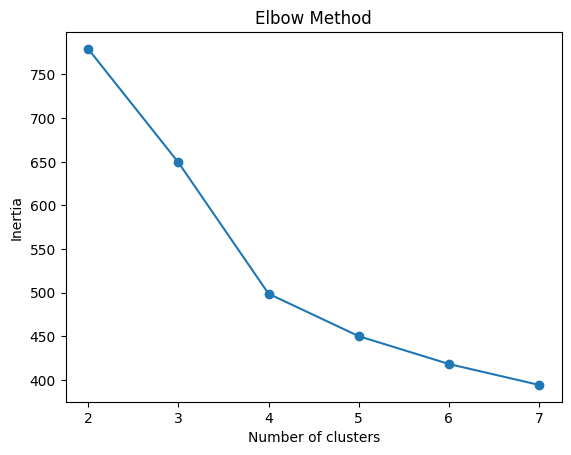

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2,8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The elbow method was used to estimate an appropriate number of clusters by examining the reduction in within-cluster variance as the cluster count increases. The point where the improvement begins to level off suggests a reasonable balance between model complexity and interpretability.

K values from 2 to 7 were tested using inertia.
The elbow point appears around K=3 or K=4.
K=3 was selected for better interpretability and model simplicity.

**Step 5C: K-Means Clustering Implementation**

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

merged_df.loc[X.index, "cluster"] = clusters

merged_df.head()

,tag_id,mean_speed,p95_speed,outlier_rate,lat_std,lon_std,event_count,age_years,hrs_indoors,prey_p_month,cluster
0,Abba-Tag,-0.705667,-0.323168,-0.059882,-0.300471,-0.161639,-0.668797,-0.718522,-0.83745,-0.154462,1.0
1,Alfie-Tag,-0.169919,-0.327755,-0.947571,-0.178827,-0.033725,0.045711,-0.718522,-0.83745,-0.154462,1.0
2,Amber-Tag,-0.111174,-0.036477,-0.609597,0.132967,0.162716,0.258690,-0.421612,-0.83745,-0.154462,1.0
3,Ares,0.409017,0.580483,-0.232248,-0.314686,-0.283393,-0.531392,-0.718522,-0.83745,-0.778488,1.0
4,Athena,0.161131,-0.343810,-0.947571,-0.342490,-0.315494,-0.510781,-0.718522,-0.83745,-0.154462,1.0


K-means clustering was applied using the selected number of clusters to group individuals with similar movement and attribute patterns. This step enables the identification of distinct behavioral profiles within the dataset.

**Step 5D: Cluster Profiling and Summary Statistics**

In [16]:
cluster_summary = merged_df.groupby("cluster")[cluster_features].mean()
cluster_summary

,mean_speed,p95_speed,outlier_rate,lat_std,lon_std,event_count,age_years,hrs_indoors,prey_p_month
cluster,,,,,,,,,
0.0,-0.757270,-0.665963,-0.349010,0.323085,0.519547,1.196218,-0.147541,-0.911386,1.877624
1.0,-0.300015,-0.339293,-0.291284,-0.188507,-0.199092,-0.220961,-0.010506,0.034991,-0.296868
2.0,1.369390,1.436108,1.085290,0.377881,0.292831,-0.040167,0.118224,0.473228,-0.315196


Summary statistics were calculated for each cluster to interpret their characteristics. By comparing feature averages across clusters, meaningful behavioral differences can be observed and described

# **Step 6: Visualization of Clustering Results**

**Step 6A: PCA Dimensionality Reduction**

In [17]:
# PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

merged_df.loc[X.index, "pca1"] = X_pca[:, 0]
merged_df.loc[X.index, "pca2"] = X_pca[:, 1]

Principal Component Analysis (PCA) was applied to reduce the multi-dimensional feature space into two principal components for visualization. This transformation preserves most of the variance in the data while allowing the clustering structure to be displayed in a two-dimensional space. The purpose of this step is not to improve clustering accuracy, but to make the patterns more interpretable for human observation.

**Step 6B: Scatter Plot of Clusters**

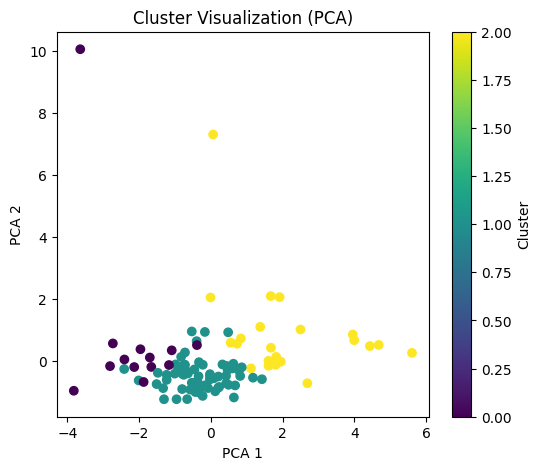

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(
    merged_df["pca1"],
    merged_df["pca2"],
    c=merged_df["cluster"],
    cmap="viridis"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization (PCA)")
plt.colorbar(label="Cluster")
plt.show()

The scatter plot shows that individuals are grouped into distinguishable clusters in the reduced two-dimensional space. Although some overlap exists between clusters, the overall separation indicates that the selected behavioral features capture meaningful differences in movement patterns. The presence of a few scattered points suggests potential outliers or individuals with mixed behavior profiles, which is common in real-world datasets.

**Step 6C: Cluster Size Distribution**

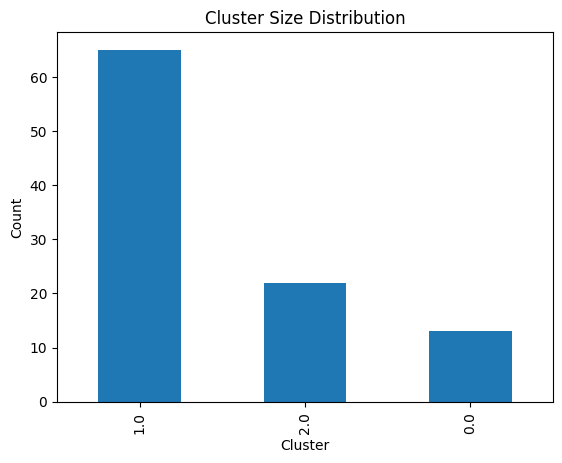

In [19]:
merged_df["cluster"].value_counts().plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

The cluster size distribution illustrates how individuals are allocated across behavioral groups. While the clusters are not perfectly balanced, no single cluster overwhelmingly dominates the dataset. This suggests that the clustering results are reasonably stable and that the segmentation is not strongly biased toward one specific behavior type. However, the smaller clusters may represent more unique or specialized movement patterns.

Overall, the visualization results support the effectiveness of the clustering approach in identifying meaningful behavioral segments.

# **Step 7: Conclusion / Discussion / Insights**

**Step 7A: Summary of Method**

In this project, unsupervised clustering techniques were applied to analyze movement behavior patterns. After data preprocessing and feature selection, K-Means clustering was used to segment individuals into behavioral groups. PCA was further applied to visualize the clustering structure in a two-dimensional space.

**Step 7B: Key Findings**

The clustering results reveal that individuals exhibit distinct movement profiles, such as high-activity groups, moderate behavior groups, and relatively inactive groups. Differences in speed, indoor time, and monthly prey activity indicate meaningful behavioral diversity within the dataset.

**Step 7C: Limitations & Future Work**

Although the clustering shows clear patterns, some overlap between clusters suggests that behavioral boundaries are not perfectly defined. Future work could explore additional features or alternative clustering algorithms, such as Hierarchical Clustering, to improve segmentation quality.

**Step 7D: Practical Implications**

These findings could be useful for understanding behavioral segmentation in animal tracking or movement analytics applications.